In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

In [2]:
df = pd.read_csv("../data/processed/master.csv")

df.shape

(394, 33)

In [3]:
df.head(5)

,player_name,team_abbr,pos,age,G,GS,MP,FG%,3P%,FT%,...,salary,team_name,wins,losses,Win_PCT,home_record,road_record,conference,overall_rank,ws_per_million
0,Shai Gilgeous-Alexander,OKC,PG,26.0,76.0,76.0,34.2,0.519,0.375,0.898,...,35859950,Oklahoma City Thunder,68,14,0.829,35-6,32-8,West,1,0.465701
1,Giannis Antetokounmpo,MIL,PF,30.0,67.0,67.0,34.2,0.601,0.222,0.617,...,48787676,Milwaukee Bucks,48,34,0.585,27-14,20-20,East,11,0.235715
2,Nikola Jokic,DEN,C,29.0,70.0,70.0,36.7,0.576,0.417,0.800,...,51415938,Denver Nuggets,50,32,0.610,26-15,24-17,West,6,0.318967
3,Anthony Edwards,MIN,SG,23.0,79.0,79.0,36.3,0.447,0.395,0.837,...,42176400,Minnesota Timberwolves,49,33,0.598,25-16,24-17,West,10,0.199164
4,Jayson Tatum,BOS,PF,26.0,72.0,72.0,36.4,0.452,0.343,0.814,...,34848340,Boston Celtics,61,21,0.744,28-13,33-8,East,3,0.272610


## Salary distribution by position

In [4]:
df["pos"].unique()

<StringArray>
['PG', 'PF', 'C', 'SG', 'SF']
Length: 5, dtype: str

In [5]:
position_map = {
    "PG": "Point Guard",
    "SG": "Shooting Guard",
    "SF": "Small Forward",
    "PF": "Power Forward",
    "C": "Center"
}

df["position_full"] = df["pos"].map(position_map)

def millions(x, pos):
    return f"{x/1e6:.0f}"

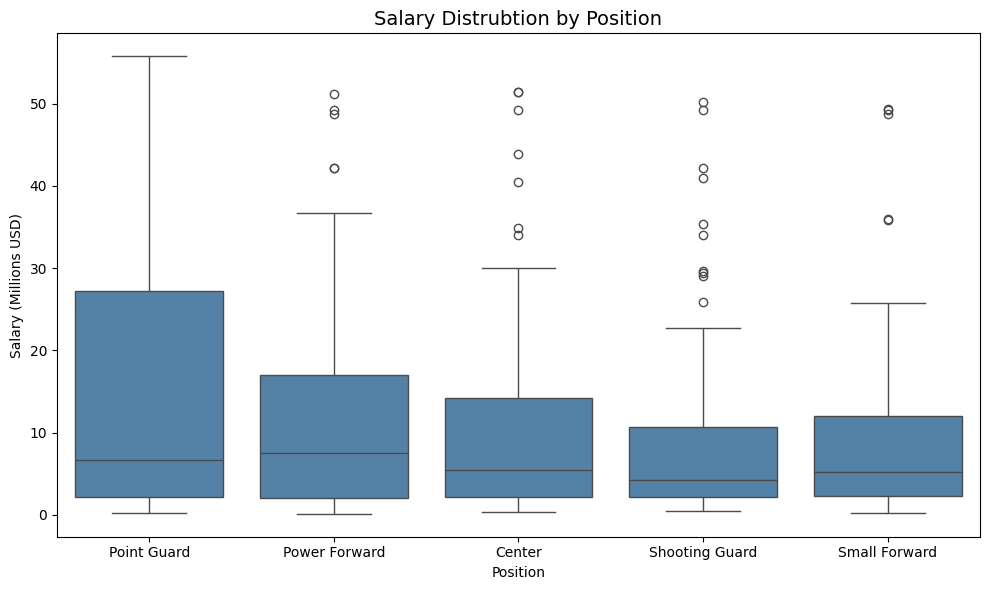

In [6]:
fig, ax = plt.subplots(figsize=(10,6))

sns.boxplot(data=df,
            x="position_full",
            y="salary", 
            ax=ax, 
            color="steelblue")

ax.set_title("Salary Distrubtion by Position", fontsize=14)
ax.set_xlabel("Position")
ax.set_ylabel("Salary (Millions USD)")
ax.yaxis.set_major_formatter(FuncFormatter(millions))

plt.tight_layout()
plt.show()

## Histograms

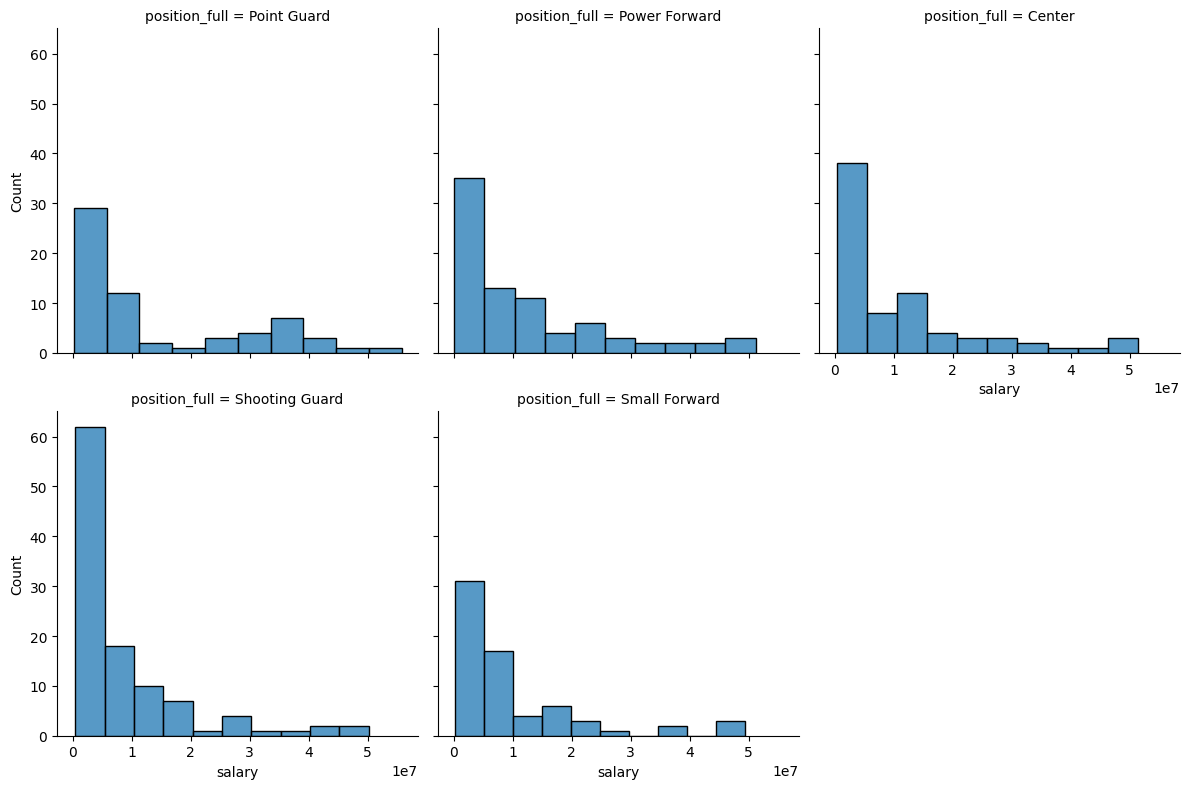

In [7]:
g = sns.FacetGrid(df, col="position_full", col_wrap=3, height=4)
g.map(sns.histplot, "salary", bins=10)
plt.tight_layout()
plt.show()

## KDE

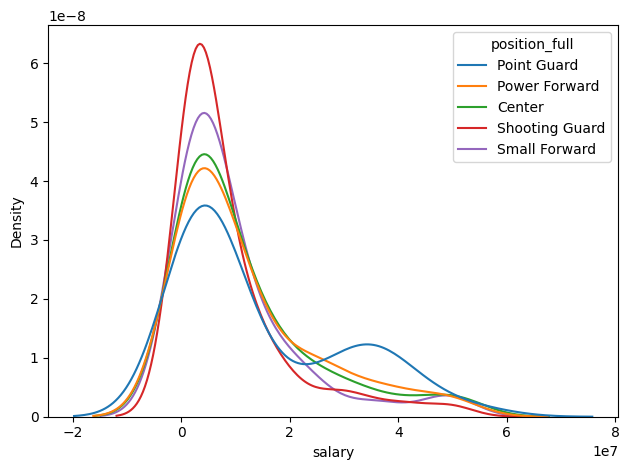

In [8]:
sns.kdeplot(data=df, x="salary", hue="position_full", common_norm=False)
plt.tight_layout()
plt.show()

## Dot Plot

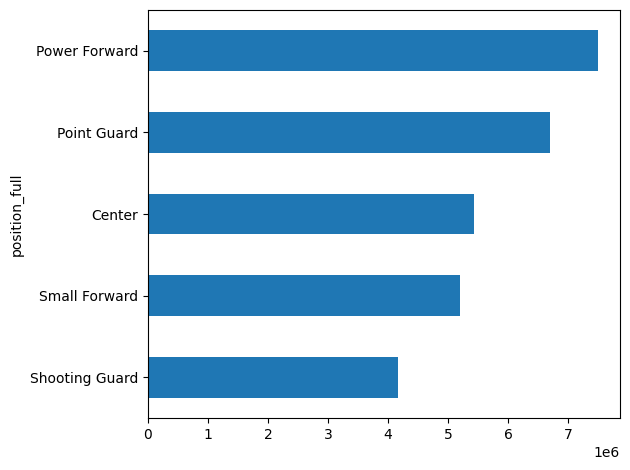

In [9]:
median_salary = df.groupby("position_full")["salary"].median().sort_values()

median_salary.plot(kind="barh")
plt.tight_layout()
plt.show()

## Boxplot + stripplot

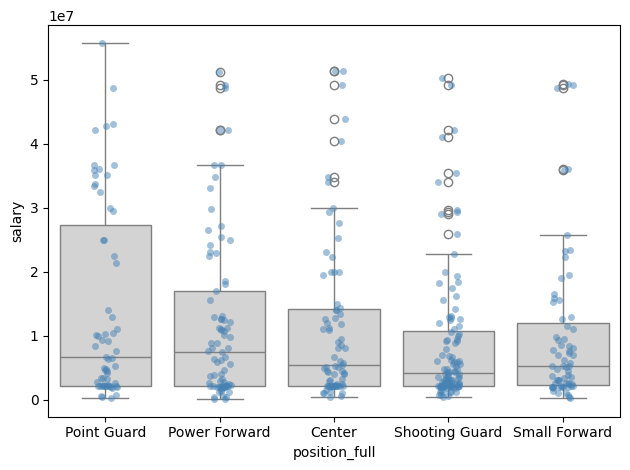

In [10]:
sns.boxplot(data=df, x="position_full", y="salary", color="lightgray")
sns.stripplot(data=df, x="position_full", y="salary", color="steelblue", alpha=0.5)
plt.tight_layout()
plt.show()

## team salary efficiency vs win %

In [11]:
team = df.groupby(["team_abbr", "team_name", "Win_PCT"]).agg(
    total_salary=("salary", "sum"),
    total_ws=("WS", "sum")
).reset_index()

team["team_ws_per_million"] = team["total_ws"] / (team["total_salary"] / 1000000)

In [12]:
# team["Win_PCT"] = team["Win_PCT"] * 100

In [13]:
team.head(5)

,team_abbr,team_name,Win_PCT,total_salary,total_ws,team_ws_per_million
0,ATL,Atlanta Hawks,0.488,124717289,32.9,0.263797
1,BOS,Boston Celtics,0.744,190264937,62.3,0.327438
2,BRK,Brooklyn Nets,0.317,78108487,20.0,0.256054
3,CHI,Chicago Bulls,0.476,123018981,30.8,0.250368
4,CHO,Charlotte Hornets,0.232,126061478,18.1,0.143581


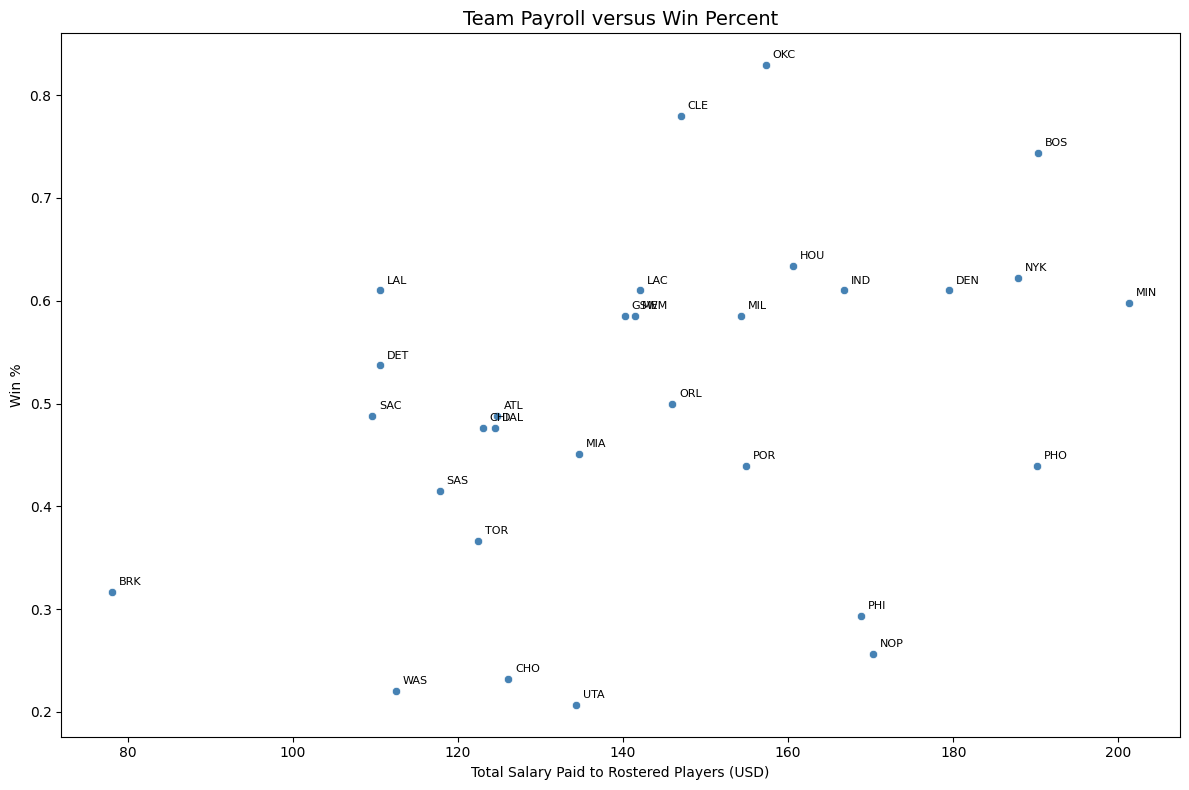

In [14]:
fig, ax = plt.subplots(figsize=(12,8))

sns.scatterplot(data=team,
            x="total_salary",
            y="Win_PCT",
            ax=ax, 
            color="steelblue")

# Label each dot with team abbreviation
for _, row in team.iterrows():
    ax.annotate(row["team_abbr"], (row["total_salary"], row["Win_PCT"]),
                textcoords="offset points", xytext=(5, 5), fontsize=8)

ax.set_title("Team Payroll versus Win Percent", fontsize=14)
ax.set_xlabel("Total Salary Paid to Rostered Players (USD)")
ax.set_ylabel("Win %")
ax.xaxis.set_major_formatter(FuncFormatter(millions))

plt.tight_layout()
plt.show()

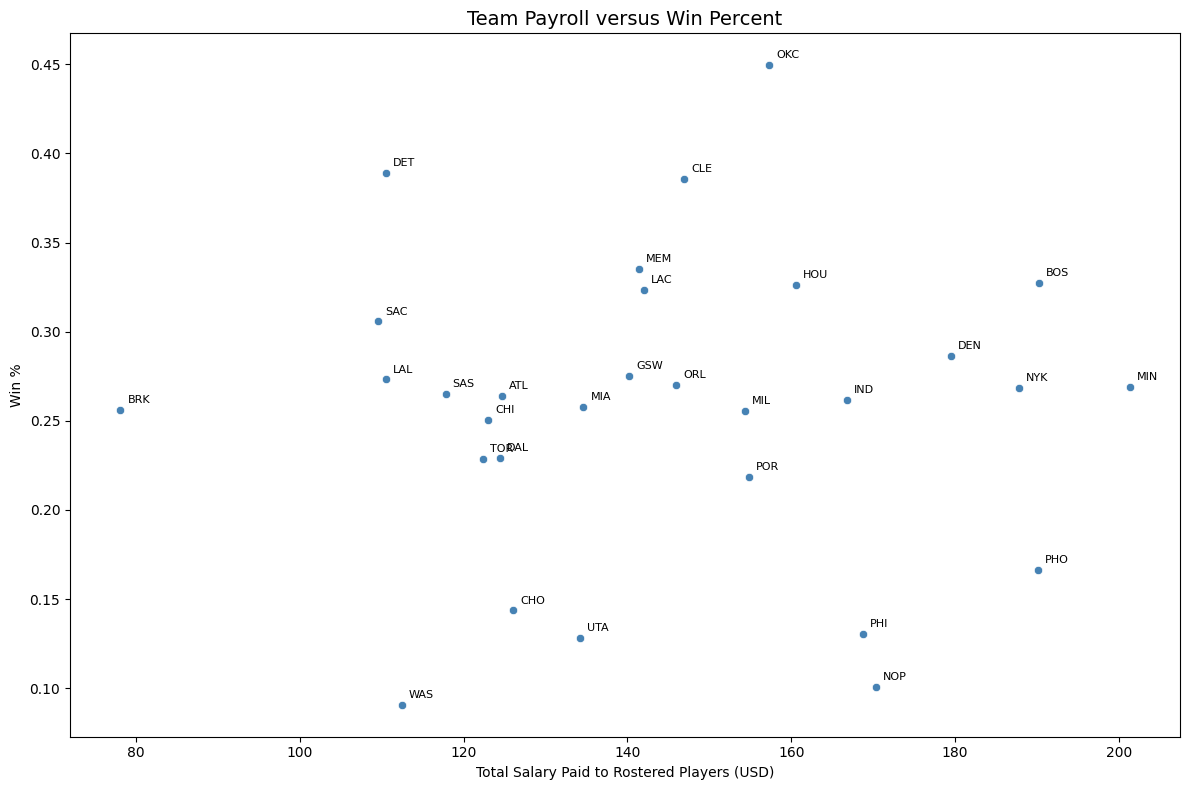

In [15]:
fig, ax = plt.subplots(figsize=(12,8))

sns.scatterplot(data=team,
            x="total_salary",
            y="team_ws_per_million",
            ax=ax, 
            color="steelblue")

# Label each dot with team abbreviation
for _, row in team.iterrows():
    ax.annotate(row["team_abbr"], (row["total_salary"], row["team_ws_per_million"]),
                textcoords="offset points", xytext=(5, 5), fontsize=8)

ax.set_title("Team Payroll versus Win Percent", fontsize=14)
ax.set_xlabel("Total Salary Paid to Rostered Players (USD)")
ax.set_ylabel("Win %")
ax.xaxis.set_major_formatter(FuncFormatter(millions))

plt.tight_layout()
plt.show()

## Top 20 Undervalued players by WS

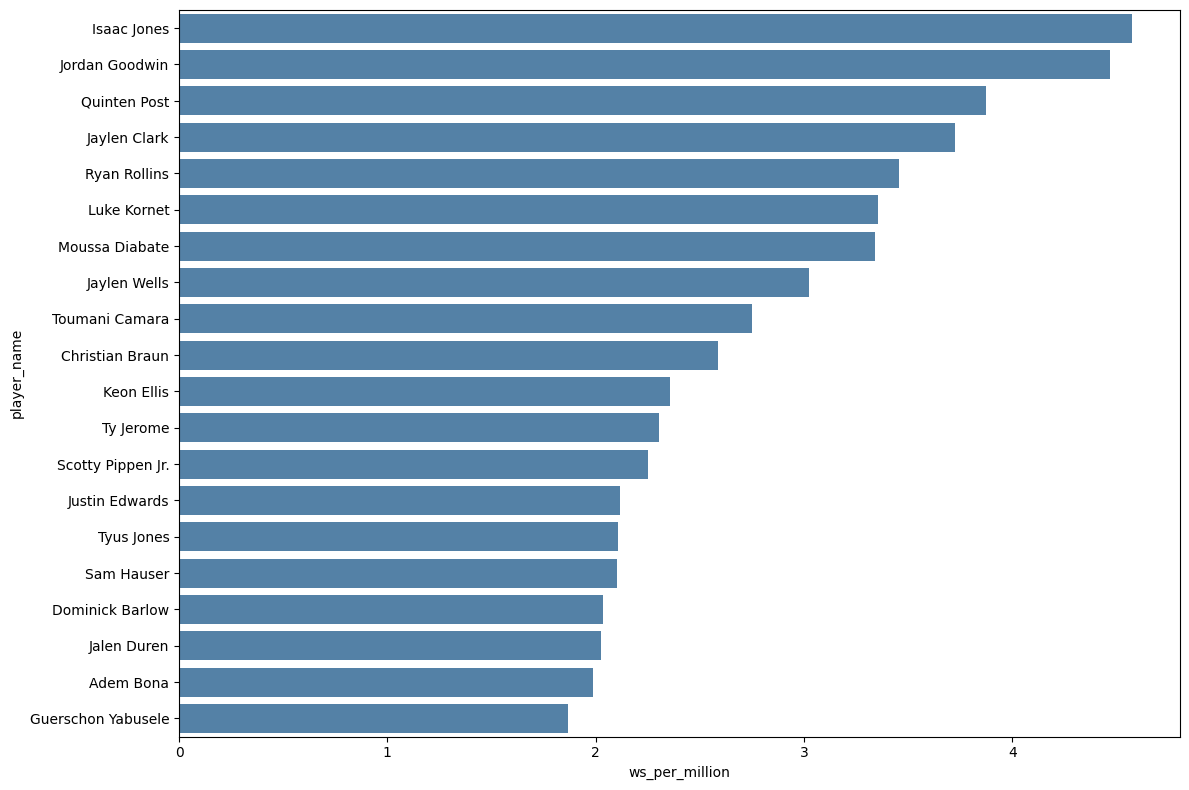

In [16]:
fig, ax = plt.subplots(figsize=(12,8))

top20 = df.nlargest(20, "ws_per_million")

sns.barplot(data=top20, 
            x="ws_per_million", 
            y="player_name",
            ax=ax,
            color="steelblue")

plt.tight_layout()
plt.show()

## Correlation Heatmap

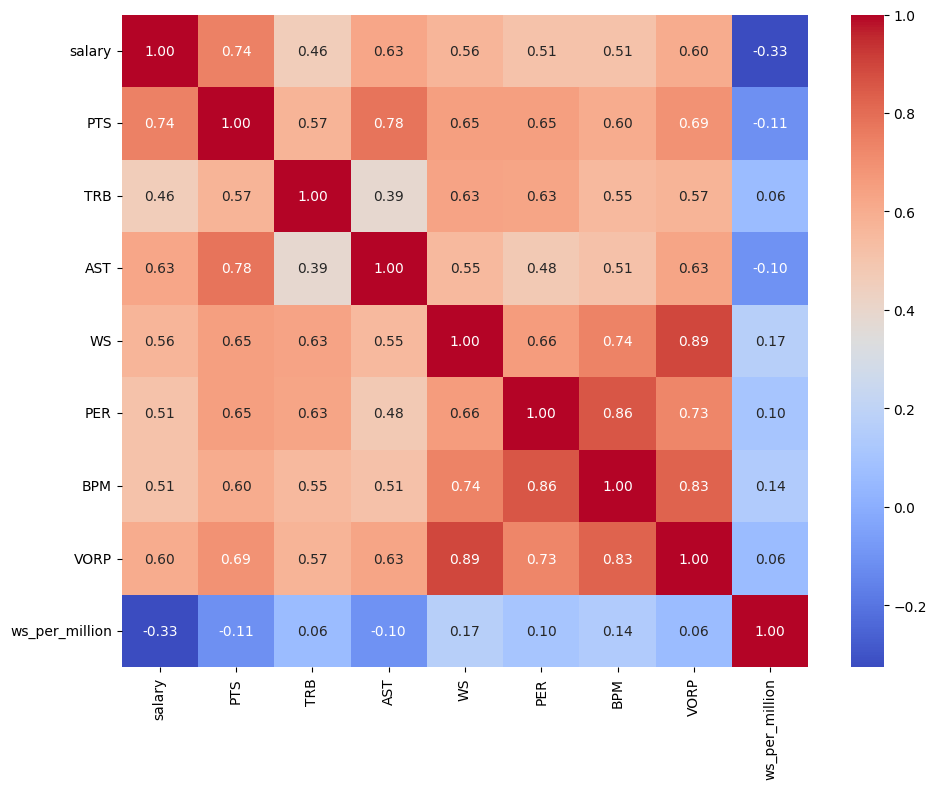

In [17]:
cols =["salary", "PTS", "TRB", "AST", "WS", "PER", "BPM", "VORP", "ws_per_million"]

fig, ax = plt.subplots(figsize=(10,8))

sns.heatmap(df[cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)

plt.tight_layout()
plt.show()

## Top 20 Undervalued players by WS and Position

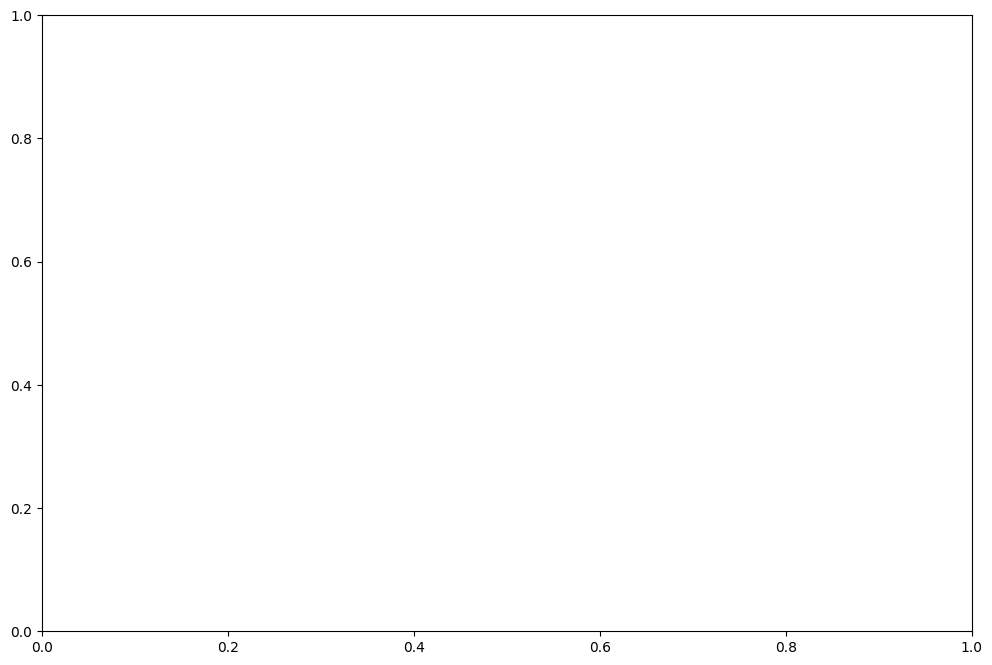

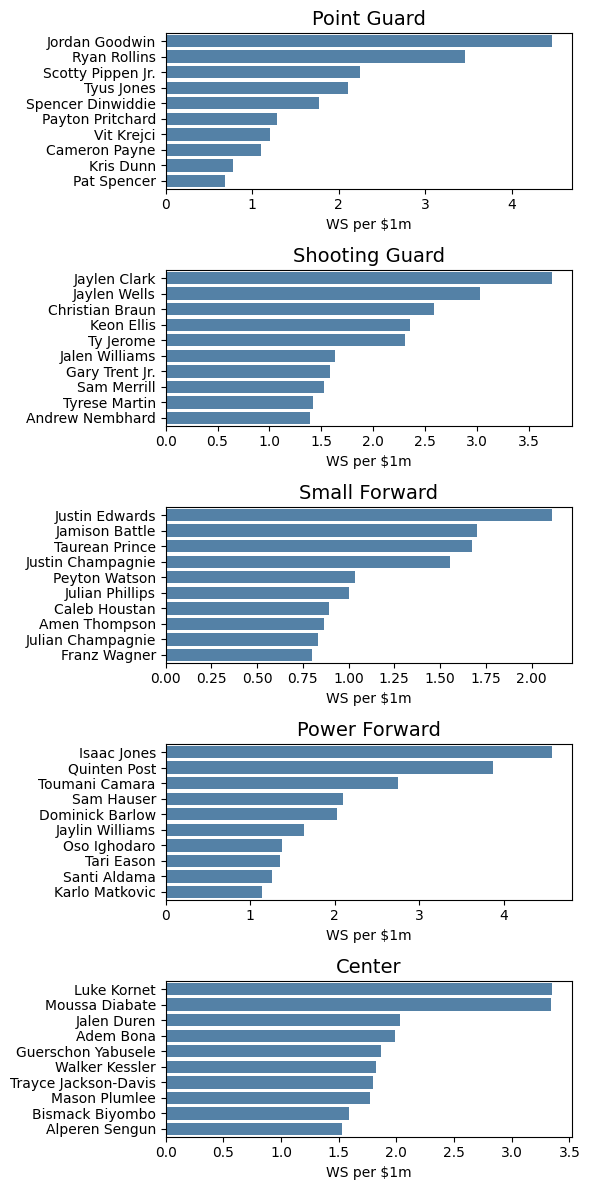

In [18]:
fig, ax = plt.subplots(figsize=(12,8))

df_temp = df[df["G"] >= 20].copy()

order = ["Point Guard", "Shooting Guard", "Small Forward", "Power Forward", "Center"]

fig, axes = plt.subplots(5, 1, figsize=(6,12))

for ax, pos in zip(axes, order):
    pos_df = df_temp[df_temp["position_full"] == pos].nlargest(10, "ws_per_million")
    sns.barplot(data=pos_df, 
                x="ws_per_million", 
                y="player_name",
                ax=ax,
                color="steelblue")
    ax.set_title(f"{pos}", fontsize=14)
    ax.set_xlabel("WS per $1m")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

# Regression

## Salary vs WS

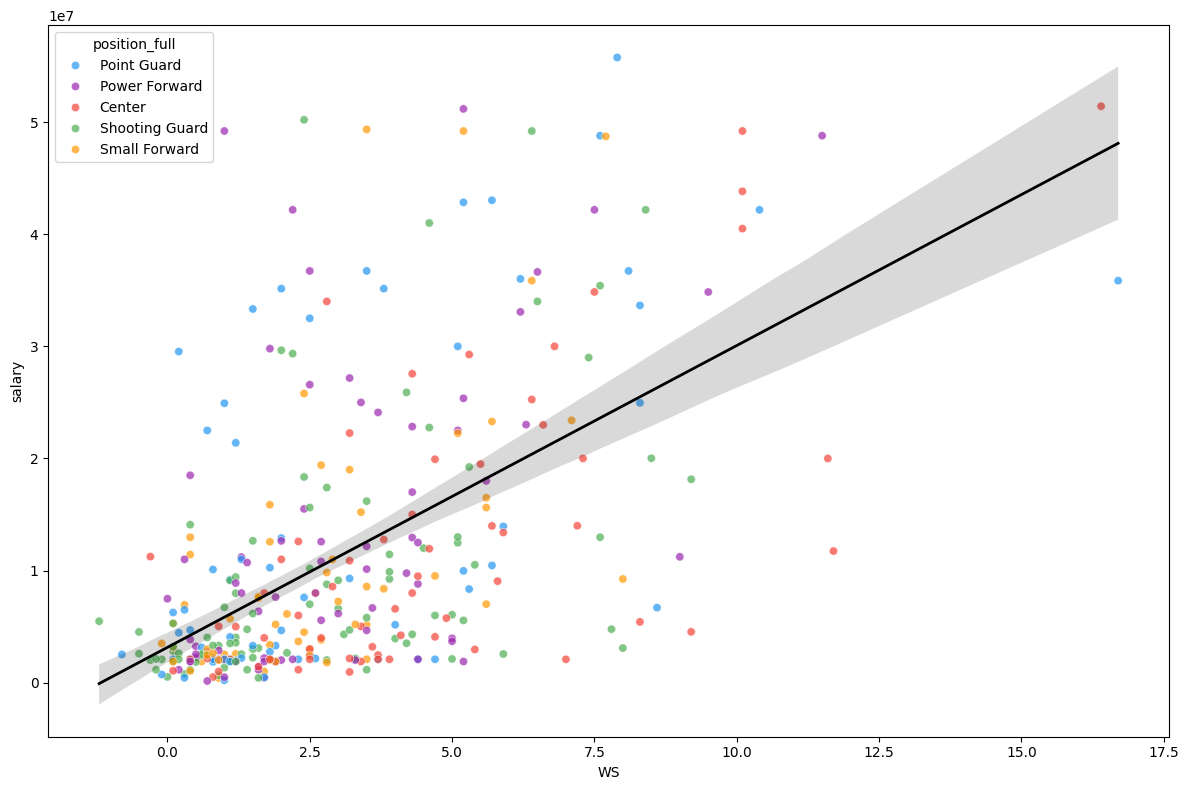

In [19]:
fig, ax = plt.subplots(figsize=(12,8))

df_temp = df[df["G"] >= 20].copy()

color = {
    "Point Guard": "#2196F3",
    "Shooting Guard": "#4CAF50",
    "Small Forward": "#FF9800",
    "Power Forward": "#9C27B0",
    "Center": "#F44336"
}
# scatter plot
sns.scatterplot(data=df_temp, 
                x="WS", 
                y="salary",
                hue="position_full",
                palette=color,
                alpha=0.7,
                ax=ax)
# regression line
sns.regplot(data=df_temp, 
                x="WS", 
                y="salary",
                scatter=False,
                line_kws={"color": "black", "linewidth": 2},
                ax=ax)

plt.tight_layout()
plt.show()


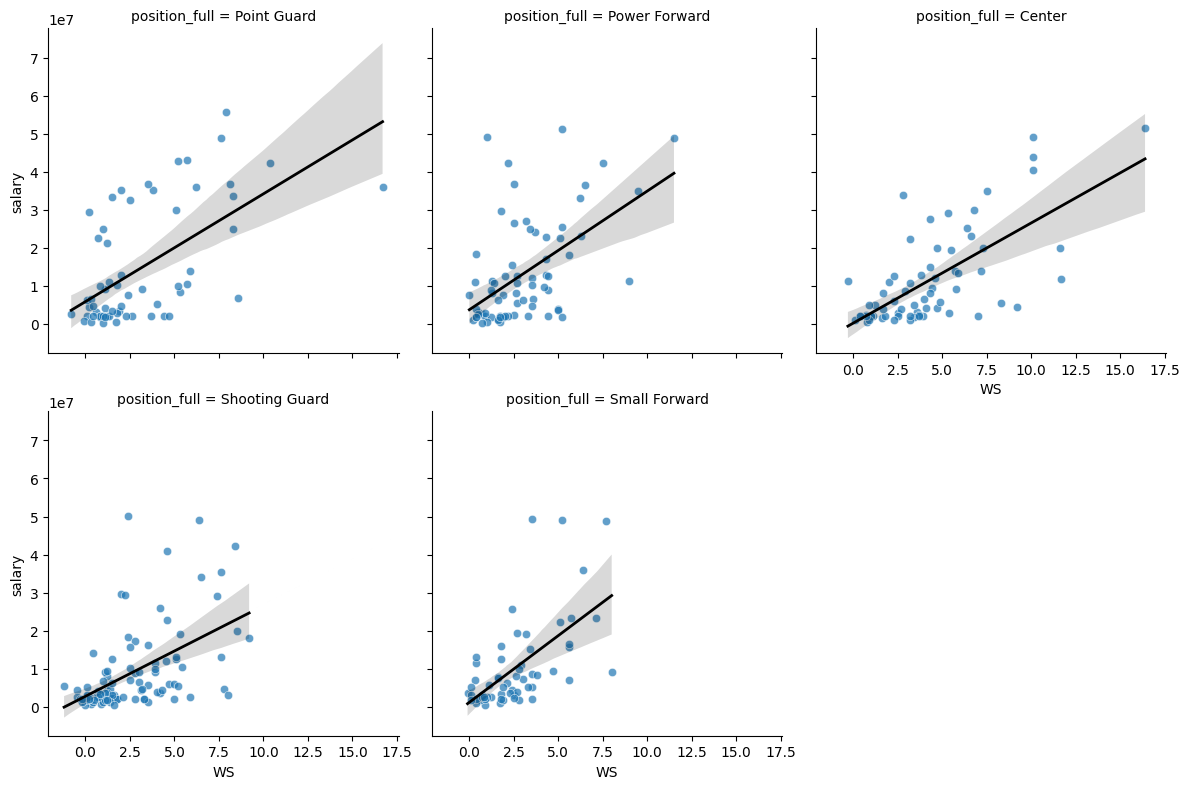

In [20]:
temp = sns.FacetGrid(df_temp, col="position_full", col_wrap=3, height=4)

temp.map_dataframe(
    sns.scatterplot,
    x="WS", 
    y="salary",
    alpha=0.7,
)
temp.map_dataframe(
    sns.regplot,
    x="WS", 
    y="salary",
    scatter=False,
    line_kws={"color": "black", "linewidth": 2}
)

g.set_titles("{col_name}")
g.tight_layout()
plt.show()

## Expected Salary vs Actual Salary

In [21]:
df.columns

Index(['player_name', 'team_abbr', 'pos', 'age', 'G', 'GS', 'MP', 'FG%', '3P%',
       'FT%', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PTS', 'PER', 'TS%', 'USG%',
       'WS', 'WS/48', 'BPM', 'VORP', 'salary', 'team_name', 'wins', 'losses',
       'Win_PCT', 'home_record', 'road_record', 'conference', 'overall_rank',
       'ws_per_million', 'position_full'],
      dtype='str')

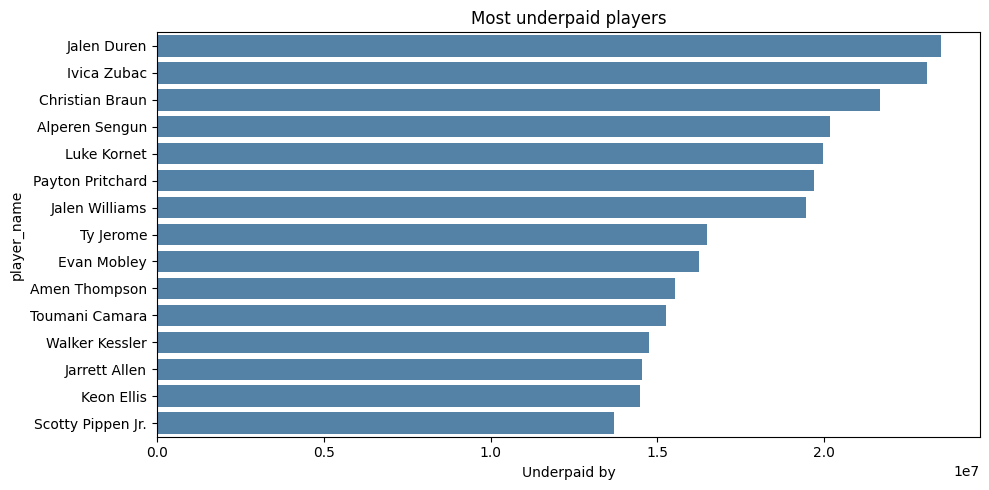

In [38]:
from sklearn.linear_model import LinearRegression
import numpy as np

df_temp = df[df["G"] >= 20].copy()
df_temp = df_temp[df_temp["WS"] > 0]  # Negative WS are net negatives
# the model gives funky numbers when we include them

X = df_temp[["WS"]]
y = df_temp[["salary"]]
model = LinearRegression().fit(X, y)


df_temp["expected_salary"] = model.predict(X)
df_temp["salary_diff"] = df_temp["expected_salary"] - df_temp["salary"]
# Positive: underpaid
# Negative: overpaid
df_temp["value_ratio"] = df_temp["salary"] / df_temp["expected_salary"]
# < 1: underpaid
# >= 1: overpaid

most_underpaid = df_temp.nlargest(15, "salary_diff")

fig, ax = plt.subplots(figsize=(10,5))

sns.barplot(data=most_underpaid, 
            x="salary_diff", 
            y="player_name", 
            ax=ax,
            color="steelblue")
ax.set_title("Most underpaid players")
ax.set_xlabel("Underpaid by")
plt.tight_layout()
plt.show()

In [39]:
df_temp.columns

Index(['player_name', 'team_abbr', 'pos', 'age', 'G', 'GS', 'MP', 'FG%', '3P%',
       'FT%', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PTS', 'PER', 'TS%', 'USG%',
       'WS', 'WS/48', 'BPM', 'VORP', 'salary', 'team_name', 'wins', 'losses',
       'Win_PCT', 'home_record', 'road_record', 'conference', 'overall_rank',
       'ws_per_million', 'position_full', 'expected_salary', 'salary_diff',
       'value_ratio'],
      dtype='str')

In [40]:
df_temp[df_temp["WS"] < 0]

,player_name,team_abbr,pos,age,G,GS,MP,FG%,3P%,FT%,...,Win_PCT,home_record,road_record,conference,overall_rank,ws_per_million,position_full,expected_salary,salary_diff,value_ratio


In [41]:
df_temp[df_temp["expected_salary"] < 0]

,player_name,team_abbr,pos,age,G,GS,MP,FG%,3P%,FT%,...,Win_PCT,home_record,road_record,conference,overall_rank,ws_per_million,position_full,expected_salary,salary_diff,value_ratio


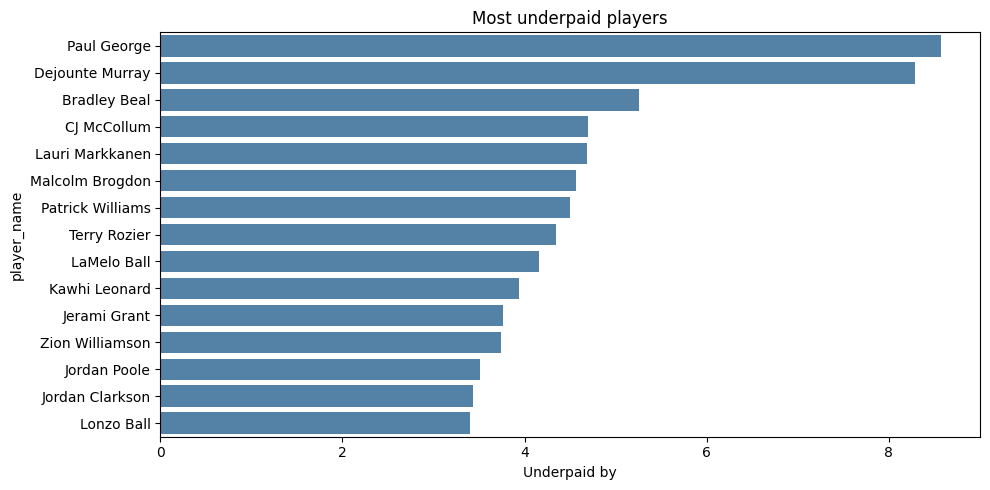

In [42]:
most_underpaid = df_temp.nlargest(15, "value_ratio")

fig, ax = plt.subplots(figsize=(10,5))

sns.barplot(data=most_underpaid, 
            x="value_ratio", 
            y="player_name", 
            ax=ax,
            color="steelblue")
ax.set_title("Most underpaid players")
ax.set_xlabel("Underpaid by")
plt.tight_layout()
plt.show()

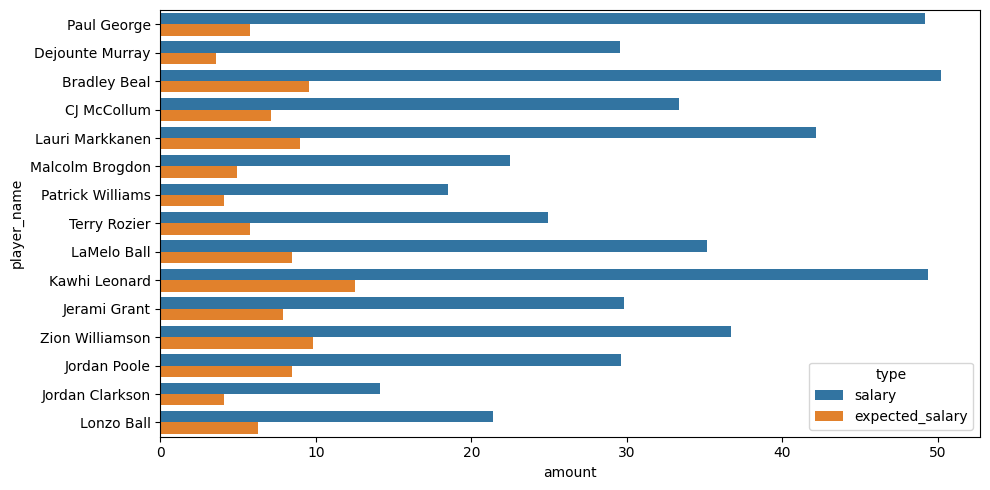

In [43]:
most_underpaid = df_temp.nlargest(15, "value_ratio")

plot_df = most_underpaid.melt(
    id_vars="player_name",
    value_vars=["salary", "expected_salary"],
    var_name="type",
    value_name="amount"
)

fig, ax = plt.subplots(figsize=(10,5))

sns.barplot(data=plot_df,
            x="amount",
            y="player_name",
            hue="type",
            ax=ax)
ax.xaxis.set_major_formatter(FuncFormatter(millions))


plt.tight_layout()
plt.show()

In [44]:
def predict_position_salary(temp_df):
    X = temp_df[["WS"]]
    y = temp_df[["salary"]]
    model = LinearRegression().fit(X, y)
    temp_df = temp_df.copy()

    temp_df["expected_salary"] = model.predict(X)
    return temp_df

In [45]:
print(df_temp["position_full"].isna().sum())

0


In [51]:
df_temp.pos.unique()

<StringArray>
['PG', 'PF', 'C', 'SG', 'SF']
Length: 5, dtype: str

In [ ]:
df_temp = df[df["G"] >= 20].copy()
df_temp = df_temp[df_temp["WS"] > 0]  # Negative WS are net negatives
# the model gives funky numbers when we include them
df_temp = df_temp.groupby("position_full", group_keys=False).apply(predict_position_salary)
df_temp["position_full"] = df_temp["pos"].map(position_map)


df_temp["salary_diff"] = df_temp["expected_salary"] - df_temp["salary"]
# Positive: underpaid
# Negative: overpaid
df_temp["value_ratio"] = df_temp["salary"] / df_temp["expected_salary"].clip(lower=1e-6)
df_temp["value_score"] = (df_temp["expected_salary"] - df_temp["salary"]) / df_temp["expected_salary"].clip(lower=1e-6)
# < 1: underpaid
# = 1: fair pay
# > 1: overpaid


In [ ]:
df_temp.groupby("position_full").agg(
    avg_sal = ("salary", "mean"),
    med_sal = ("salary", "median"),
    std_sal = ("salary", "std"),
    max_sal = ("salary", "max"),
    min_sal = ("salary", "min")
).reset_index()

11712424.08908046
6165833.5
12900532.561635753


,position_full,avg_sal,med_sal,std_sal,max_sal,min_sal
0,Center,1.146130e+07,5756880.0,1.253529e+07,51415938,503884
1,Point Guard,1.498857e+07,7980063.5,1.542520e+07,55761216,223718
2,Power Forward,1.301052e+07,8404780.0,1.352126e+07,51179021,152957
3,Shooting Guard,9.522368e+06,4710144.0,1.116421e+07,50203930,429323
4,Small Forward,1.043809e+07,6539122.5,1.172915e+07,49350000,425619


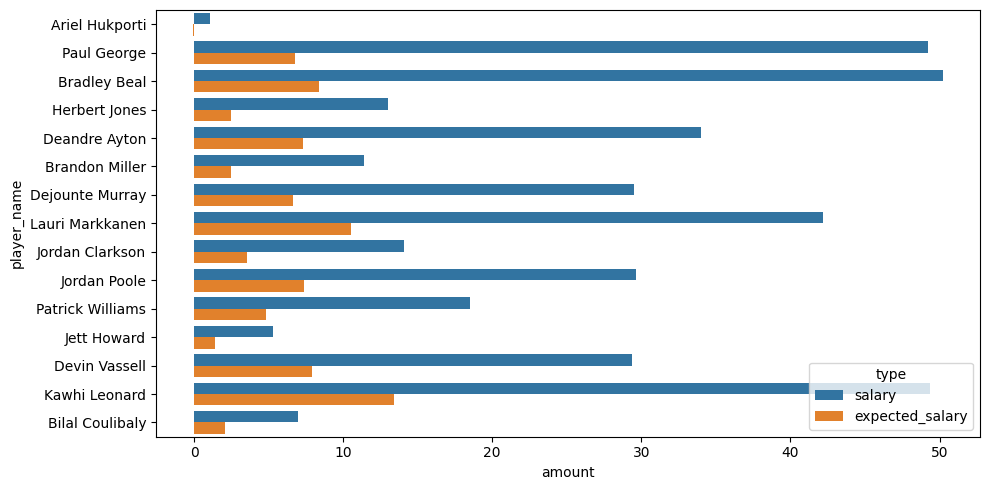

In [67]:
most_underpaid = df_temp.nlargest(15, "value_ratio")

plot_df = most_underpaid.melt(
    id_vars="player_name",
    value_vars=["salary", "expected_salary"],
    var_name="type",
    value_name="amount"
)

fig, ax = plt.subplots(figsize=(10,5))

sns.barplot(data=plot_df,
            x="amount",
            y="player_name",
            hue="type",
            ax=ax)
ax.xaxis.set_major_formatter(FuncFormatter(millions))


plt.tight_layout()
plt.show()

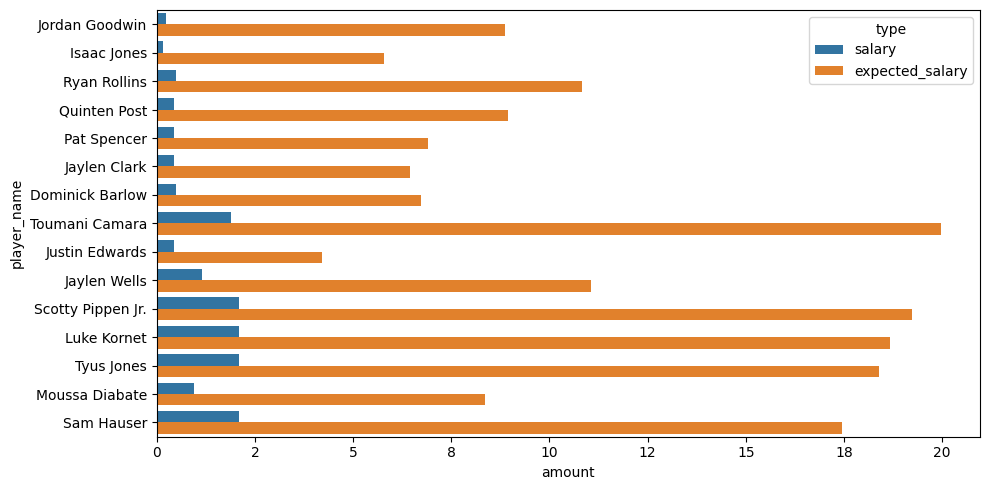

In [69]:
most_underpaid = df_temp.nlargest(15, "value_score")

plot_df = most_underpaid.melt(
    id_vars="player_name",
    value_vars=["salary", "expected_salary"],
    var_name="type",
    value_name="amount"
)

fig, ax = plt.subplots(figsize=(10,5))

sns.barplot(data=plot_df,
            x="amount",
            y="player_name",
            hue="type",
            ax=ax)
ax.xaxis.set_major_formatter(FuncFormatter(millions))


plt.tight_layout()
plt.show()

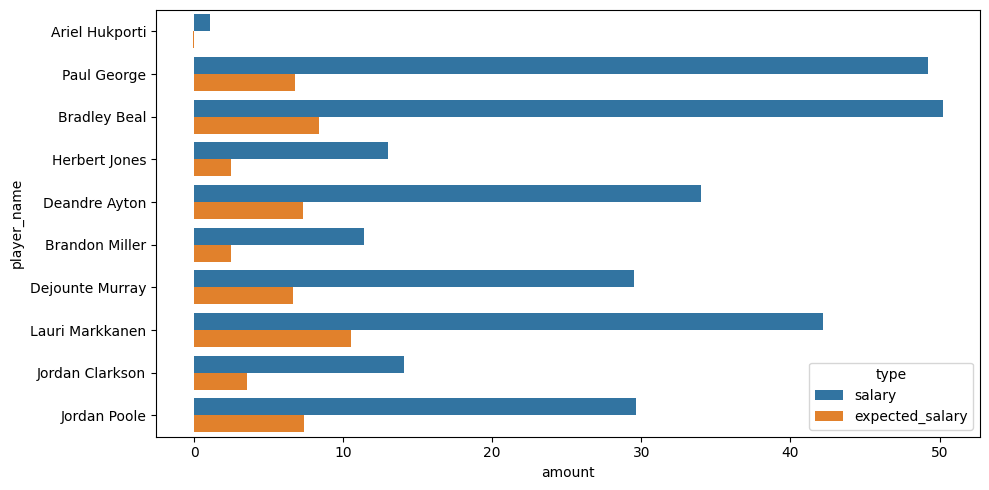

In [71]:
most_underpaid = df_temp.nsmallest(10, "value_score")

plot_df = most_underpaid.melt(
    id_vars="player_name",
    value_vars=["salary", "expected_salary"],
    var_name="type",
    value_name="amount"
)

fig, ax = plt.subplots(figsize=(10,5))

sns.barplot(data=plot_df,
            x="amount",
            y="player_name",
            hue="type",
            ax=ax)
ax.xaxis.set_major_formatter(FuncFormatter(millions))


plt.tight_layout()
plt.show()

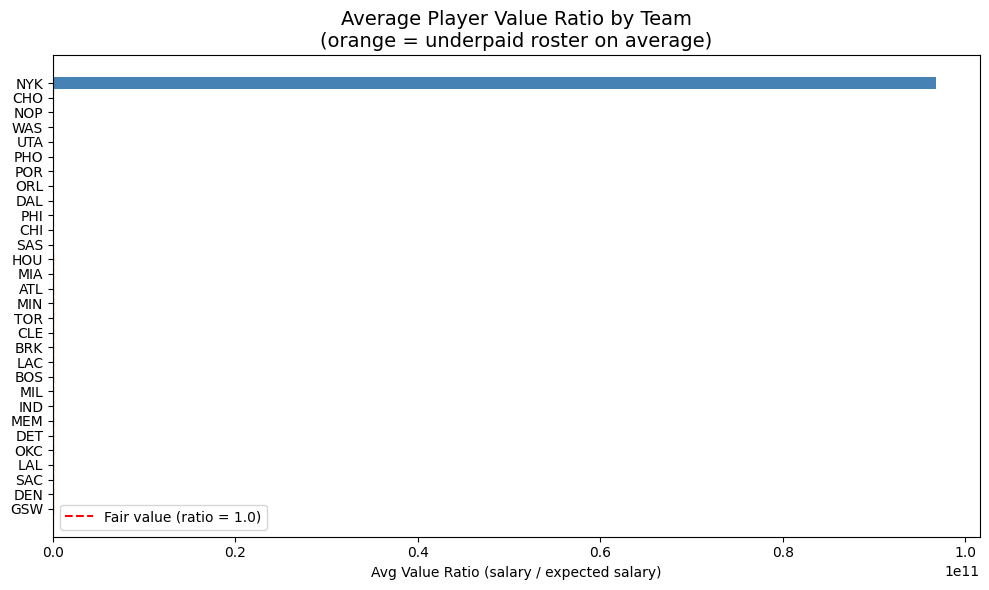

In [68]:
team_value = df_temp.groupby("team_abbr")["value_ratio"].mean().sort_values()


fig, ax = plt.subplots(figsize=(10,6))

bars = ax.barh(team_value.index, team_value.values, color="steelblue")
# bars = ax.barh(team_value.reset_index()["team_abbr"], team_value.reset_index()["team_abbr"], color="steelblue")
# team_value.reset_index()

for bar, val in zip(bars, team_value.values):
    if val < 1.0:
        bar.set_color("#FF9800")

ax.axvline(x=1.0, color="red", linestyle="--", linewidth=1.5, label="Fair value (ratio = 1.0)")
ax.set_title("Average Player Value Ratio by Team\n(orange = underpaid roster on average)", fontsize=14)
ax.set_xlabel("Avg Value Ratio (salary / expected salary)")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
team_value.reset_index()

## Mean vs Median Salary

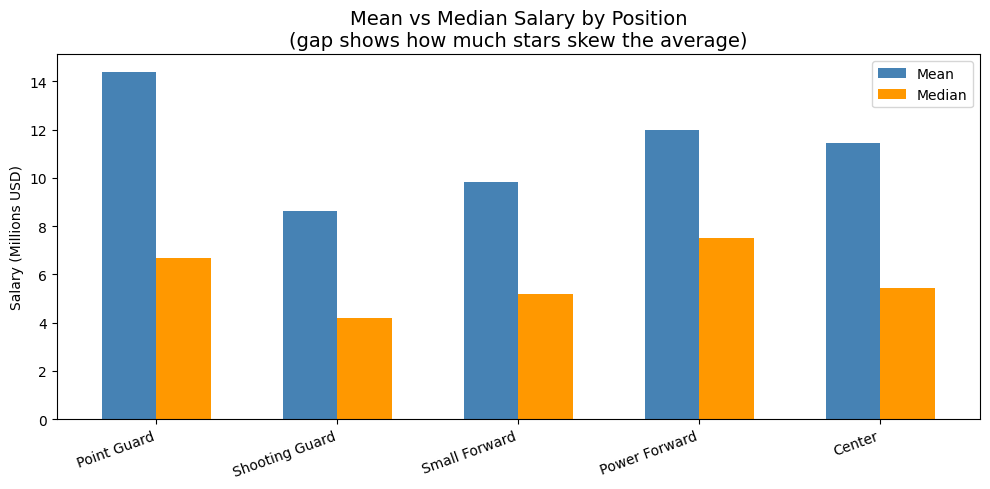

In [76]:
fig, ax = plt.subplots(figsize=(10, 5))

pos_order = ["Point Guard", "Shooting Guard", "Small Forward", "Power Forward", "Center"]

# Plot both mean and median as grouped bars
salary_stats = df.groupby("position_full")["salary"].agg(["mean", "median"]).loc[pos_order]
salary_stats = salary_stats / 1_000_000  # convert to millions

salary_stats.plot(kind="bar", ax=ax, color=["steelblue", "#FF9800"], width=0.6)

ax.set_title("Mean vs Median Salary by Position\n(gap shows how much stars skew the average)", fontsize=14)
ax.set_xlabel("")
ax.set_ylabel("Salary (Millions USD)")
ax.set_xticklabels(pos_order, rotation=20, ha="right")
ax.legend(["Mean", "Median"])

plt.tight_layout()
plt.show()

## Salary vs VORP

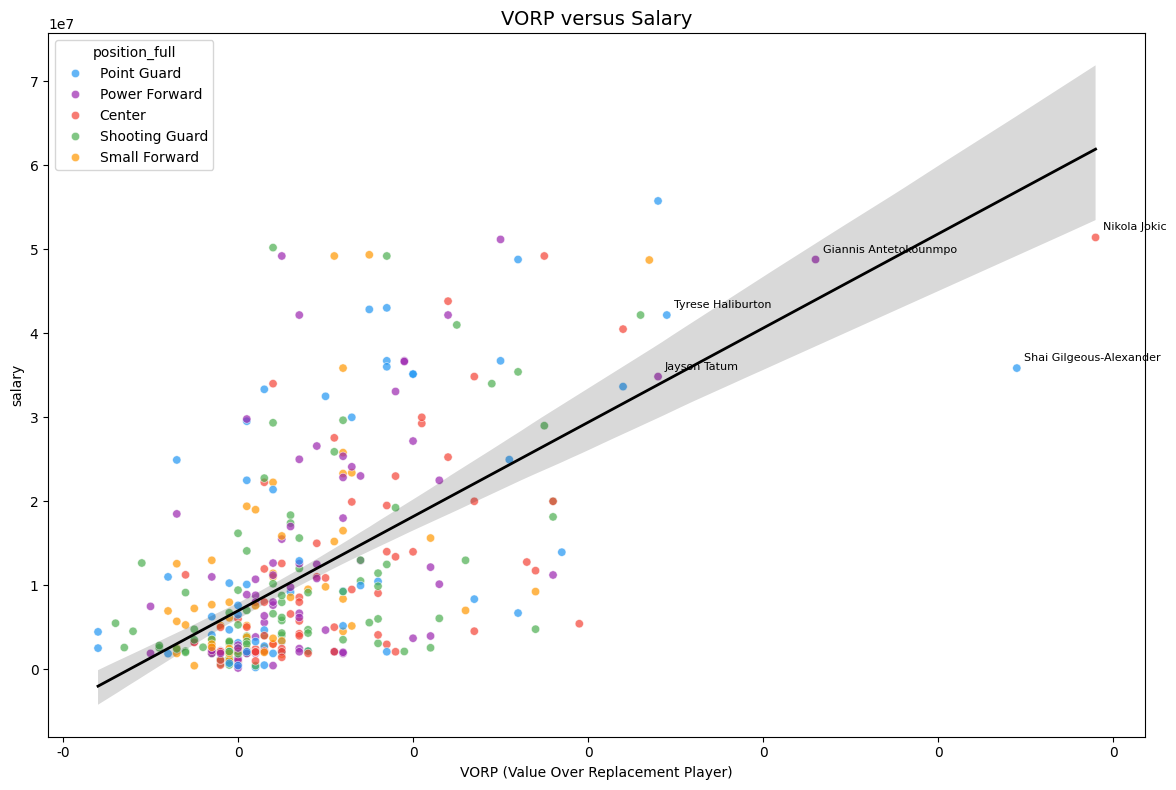

In [77]:
fig, ax = plt.subplots(figsize=(12,8))

df_temp = df[df["G"] >= 20].copy()

# scatter plot
sns.scatterplot(data=df_temp, 
                x="VORP", 
                y="salary",
                hue="position_full",
                palette=color,
                alpha=0.7,
                ax=ax)
# regression line
sns.regplot(data=df_temp, 
                x="VORP", 
                y="salary",
                scatter=False,
                line_kws={"color": "black", "linewidth": 2},
                ax=ax)

# Label each dot with team abbreviation
top_vorp = df_temp.nlargest(5, "VORP")
for _, row in top_vorp.iterrows():
    ax.annotate(row["player_name"], (row["VORP"], row["salary"]),
                textcoords="offset points", xytext=(5, 5), fontsize=8)

ax.set_title("VORP versus Salary", fontsize=14)
ax.set_xlabel("VORP (Value Over Replacement Player)")
ax.set_ylabel("salary")
ax.xaxis.set_major_formatter(FuncFormatter(millions))

plt.tight_layout()
plt.show()

## Team WS per million

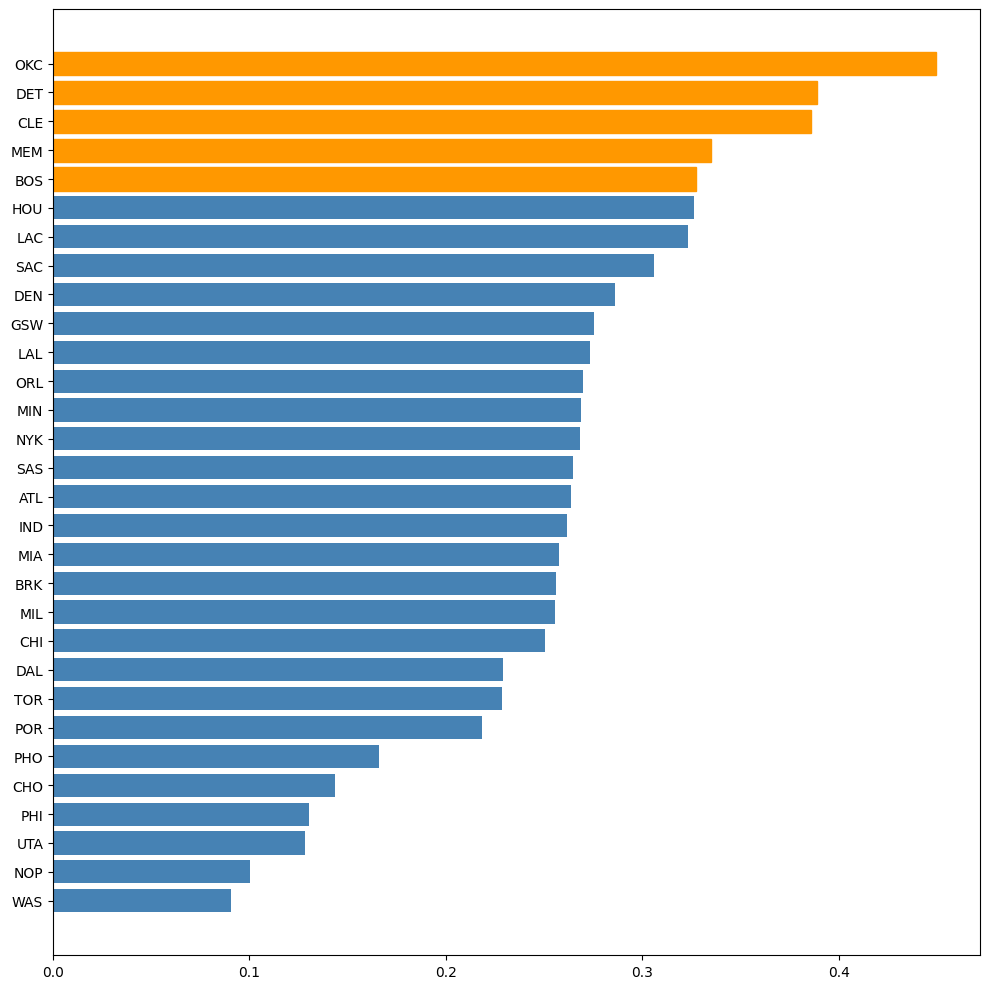

In [78]:
team_ranked = team.sort_values("team_ws_per_million", ascending=True) 

fig, ax = plt.subplots(figsize=(10, 10)) 

bars = ax.barh(team_ranked["team_abbr"], team_ranked["team_ws_per_million"], color="steelblue")


top5_abbrs = team_ranked.nlargest(5, "team_ws_per_million")["team_abbr"].tolist()
for bar, abbr in zip(bars, team_ranked["team_abbr"]):
    if abbr in top5_abbrs:
        bar.set_color("#FF9800")

plt.tight_layout()
plt.show()

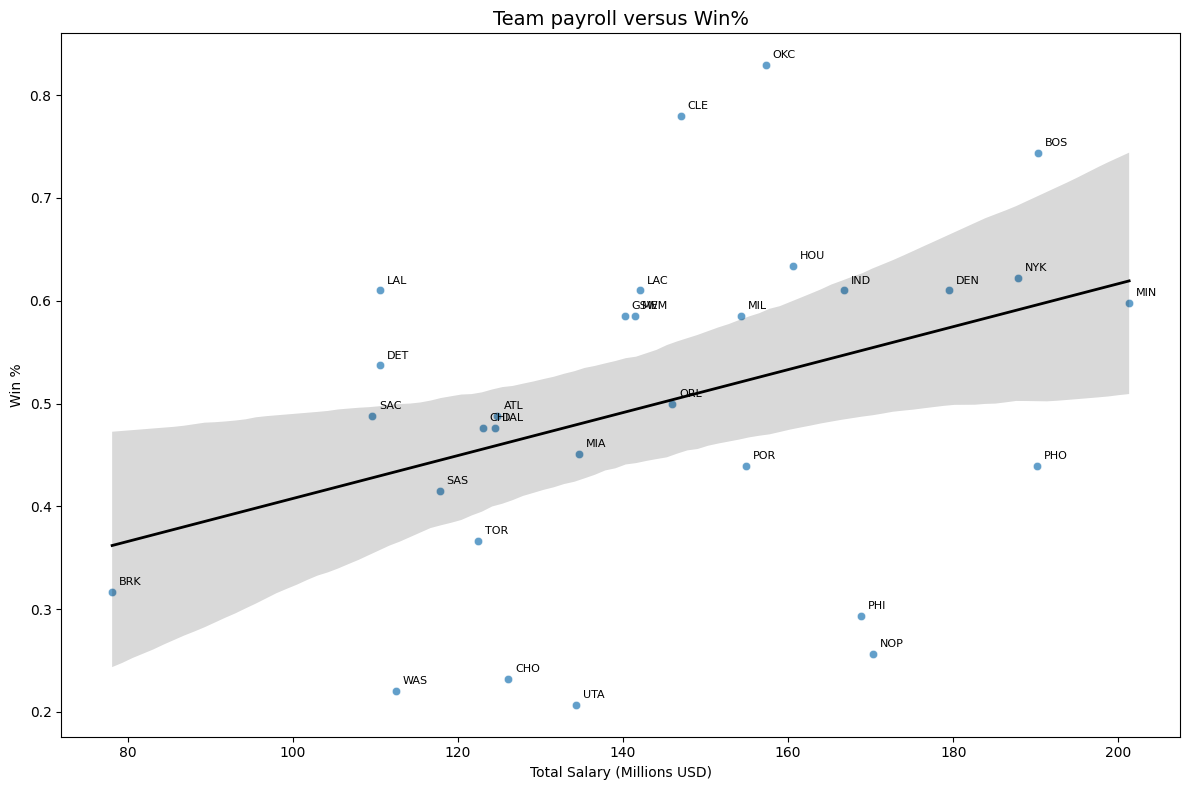

In [79]:
fig, ax = plt.subplots(figsize=(12,8))


# scatter plot
sns.scatterplot(data=team, 
                x="total_salary", 
                y="Win_PCT",
                alpha=0.7,
                ax=ax)
# regression line
sns.regplot(data=team, 
                x="total_salary", 
                y="Win_PCT",
                scatter=False,
                line_kws={"color": "black", "linewidth": 2},
                ax=ax)


# Label each dot with team abbreviation
for _, row in team.iterrows():
    ax.annotate(row["team_abbr"], (row["total_salary"], row["Win_PCT"]),
                textcoords="offset points", xytext=(5, 5), fontsize=8)

ax.set_title("Team payroll versus Win%", fontsize=14)
ax.set_xlabel("Total Salary (Millions USD)")
ax.set_ylabel("Win %")
ax.xaxis.set_major_formatter(FuncFormatter(millions))

plt.tight_layout()
plt.show()

## 